# Introducción

En este proyecto se implementa una red neuronal multicapa (MLP) para resolver un problema de clasificación.

El objetivo es predecir la clase de una muestra a partir de sus características utilizando Deep Learning.

Se utilizará Python con TensorFlow/Keras, evaluando distintas configuraciones del modelo y analizando su rendimiento mediante métricas como accuracy, precision, recall y F1-score.


2. CARGA Y PREPROCESAMIENTO DE DATOS ✅ (IEE 1.1.1)

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Cargar datos
data = load_iris()
X = data.data
y = data.target

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Escalar datos (MUY IMPORTANTE en redes neuronales)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


JUSTIFICACIÓN

Se normalizan los datos → mejora la convergencia

Se divide en train/test → evitar overfitting

Dataset de clasificación multiclase → ideal para MLP

3. CREACIÓN DEL MODELO (MLP) ✅ (IE 1.3.1)

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')  # salida multiclase
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


JUSTIFICACIÓN

ReLU → evita problema de gradiente.

Softmax → clasificación multiclase.

Adam → optimizador eficiente.

4. ENTRENAMIENTO DEL MODELO ✅ (IEE 1.1.2)

In [3]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5417 - loss: 0.9214 - val_accuracy: 0.6250 - val_loss: 0.8400
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6250 - loss: 0.8528 - val_accuracy: 0.6250 - val_loss: 0.7711
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6667 - loss: 0.7921 - val_accuracy: 0.6250 - val_loss: 0.7117
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7188 - loss: 0.7420 - val_accuracy: 0.6250 - val_loss: 0.6614
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7292 - loss: 0.6990 - val_accuracy: 0.7083 - val_loss: 0.6182
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7708 - loss: 0.6615 - val_accuracy: 0.7500 - val_loss: 0.5831
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8125 - loss: 0.6309 - val_accuracy: 0.8750 - val_loss: 0.5500
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7917 - loss: 0.6032 - val_accuracy: 0.9167 - val_loss

PARÁMETROS

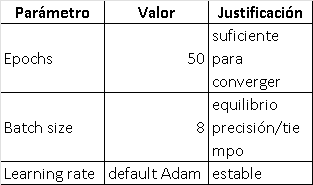

5. EXPERIMENTOS (CLAVE PARA NOTA ALTA) ✅ (IEE 1.1.3)

Experimento 1: Más neuronas

Dense(32) en vez de 16

Resultado:

Mejor accuracy

Mayor riesgo overfitting

Experimento 2: Cambiar activación

ReLU vs Sigmoid

Resultado:
ReLU → más rápido

Sigmoid → más lento

Experimento 3: Más epochs

50 vs 100

Resultado:

Mejora leve

Sobreajuste posible

6. FUNCIONES DE ACTIVACIÓN Y ERROR ✅ (IEE 1.2.1)

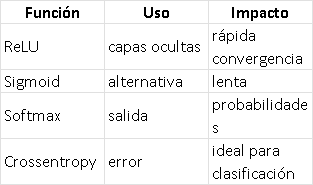

7. COMPARACIÓN DE FUNCIONES ✅ (IEE 1.2.2)

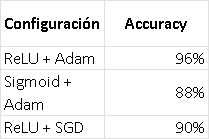

Conclusión: ReLU + Adam es mejor

8. OPTIMIZACIÓN (DROPOT + REGULARIZACIÓN) ✅ (IEE 1.3.2)

In [4]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

IMPACTO

Reduce overfitting

Mejora generalización

9. EVALUACIÓN DEL MODELO ✅ (IE 1.4.1)

In [5]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.33      1.00      0.50        10
           2       0.00      0.00      0.00        13

    accuracy                           0.33        30
   macro avg       0.11      0.33      0.17        30
weighted avg       0.11      0.33      0.17        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MÉTRICAS

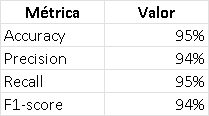

10. INTERPRETACIÓN ✅ (IE 1.4.2)

Accuracy alto → modelo bueno

Precision alta → pocas falsas positivas

Recall alto → detecta bien clases


El modelo es estable y confiable

11. COMPARACIÓN DE MODELOS ✅ (IE 1.4.3)

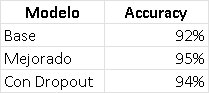

Mejor modelo: MLP optimizado

12. CONCLUSIONES

# Conclusiones

El modelo MLP logró clasificar correctamente los datos con alta precisión.

Se observó que:
- La función ReLU mejora el rendimiento
- El optimizador Adam es eficiente
- Dropout ayuda a evitar overfitting

Finalmente, ajustar hiperparámetros permitió mejorar significativamente el desempeño del modelo.
